# [실습] 의사결정나무와 앙상블

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🌳 [실습] 의사결정나무와 앙상블 — 여러 모델을 모으면 강해진다

## — 같은 데이터, 더 강한 도구. 그런데 정말 더 강할까?

개념 노트북에서 의사결정나무부터 랜덤포레스트·부스팅까지 걸어왔습니다. 이제 그 도구들을 **지난 순서에서 쓰던 그 데이터**에 그대로 얹습니다. 같은 문제·같은 열·같은 분할이므로, 달라지는 것은 **모델뿐**입니다 — 그래서 비교가 정직해집니다.

> 🤖 **오늘의 AI 활용 규칙 — 손코딩 단계:** 코드는 손으로 씁니다. AI에게는 개념 *설명*만 요청하세요. (자세한 이유는 개념 노트북 Part 0)

## 📋 오늘의 미션

지난 순서에서 마케팅팀에 첫 답을 드렸습니다. 로지스틱 회귀로 구매 전환을 예측해 정확도 약 0.880을 냈습니다. 그런데 팀장이 이렇게 물어왔습니다.

> 🧑‍💼 "요즘 다들 쓴다는 **XGBoost** 같은 걸로 바꾸면 얼마나 더 좋아집니까? 그리고 **어떤 행동이 구매를 예고하는지**도 알려주실 수 있나요? 마케팅 예산을 어디에 쓸지 정해야 합니다."

두 질문 모두 오늘 배운 것으로 답할 수 있습니다. 성능 비교는 **4단 비교표**로, 두 번째 질문은 **피처 중요도**로 답합니다.

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | 단일 트리를 얹어 본다 | 학습-테스트 격차 읽기 |
| 2 | 가지치기로 격차를 줄인다 | 과적합 제어 |
| 3 | 숲과 부스팅 — 4단 비교표 | 베이스라인 대비 정직한 비교 |
| 4 | 피처 중요도를 비즈니스 언어로 | 숫자를 액션으로 번역 |
| 5 | 모델 카드 v2 완성 | 근거를 남기는 습관 (**제출물**) |

> ⚠️ **미리 알아두기:** 오늘도 지표는 **정확도**만 씁니다. 구매가 15.5%뿐인 데이터에서 정확도가 왜 위험한지는 이후 순서(평가 지표·불균형)에서 다룹니다. 오늘은 "모델을 바꾸면 무엇이 달라지나"에 집중하고, 그 한계를 **모델 카드에 적어 두는 것**까지가 과제입니다.

# ⚙️ 데이터 준비

지난 순서와 **똑같은 데이터·똑같은 열**을 씁니다. 저장소가 하나의 분석 포트폴리오로 쌓이도록, 순서마다 데이터를 갈아타지 않습니다.

| 데이터 | 내용 | 출처·라이선스 |
| --- | --- | --- |
| **Online Shoppers Purchasing Intention** | 온라인 스토어 방문 세션 12,330건 — 페이지 방문·체류·이탈률 등 18개 열, 타깃 `Revenue`(구매 여부) | [UCI 468](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · CC BY 4.0 |

`[C1]` 셀은 **최초 실행 시에만** 내려받아 `data/`에 저장합니다(지난 순서에서 받았다면 그 파일을 씁니다). 여전히 **수치형 10개 열만** 사용합니다 — 문자 열을 넣는 법은 피처·`Pipeline` 순서에서 배웁니다. 트리는 스케일링이 필요 없어 로지스틱에만 `StandardScaler`를 씁니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. 단일 트리를 얹어 본다

먼저 비교의 기준선을 세웁니다. 지난 순서의 두 숫자 — **베이스라인(`DummyClassifier`)** 과 **로지스틱 회귀** — 를 다시 구하고, 그 옆에 **의사결정나무**를 나란히 놓습니다.

중요한 것이 하나 더 있습니다. 개념 노트북에서 배운 대로, 트리는 **학습 점수와 테스트 점수를 함께** 봐야 합니다. 테스트 점수만 보면 무슨 일이 벌어졌는지 알 수 없습니다.

```
[문제 1]
1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
   ① DummyClassifier(strategy="most_frequent")
   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음
```

> 🤔 **예상해 볼까요?** 의사결정나무는 로지스틱 회귀보다 훨씬 유연한 모델입니다. 테스트 정확도가 **로지스틱(약 0.880)을 넘을까요?** 그리고 세 모델 중 학습-테스트 격차가 가장 큰 것은 무엇일까요?

▶ 실행: [C2]

In [2]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1) X, y 준비 (y는 불리언 → 0/1 정수로 변환)
X = shoppers[NUM_COLS].copy()
y = shoppers["Revenue"].astype(int)

# 8:2 분리 (양성 비율이 15.5%뿐이라 stratify 필수, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 로지스틱 회귀만 스케일링 — 학습 데이터로만 fit, 학습·테스트에 각각 transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2) 세 모델을 동일한 방식으로 학습·평가하고 rows에 dict로 누적
models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), X_train, X_test),
    "LogisticRegression": (LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled),
    "DecisionTree": (DecisionTreeClassifier(), X_train, X_test),
}

rows = []
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    rows.append({
        "모델": name,
        "학습 정확도": train_acc,
        "테스트 정확도": test_acc,
        "격차": train_acc - test_acc,
    })

results = pd.DataFrame(rows).round(4)
print(results.to_string(index=False))

                모델  학습 정확도  테스트 정확도     격차
   DummyClassifier  0.8453   0.8451 0.0002
LogisticRegression  0.8839   0.8796 0.0044
      DecisionTree  0.9998   0.8423 0.1575


<details>
<summary>(클릭) 💡 힌트</summary>

- `y`는 불리언이므로 `.astype(int)`로 0/1로 바꿉니다.
- 분류에서는 `stratify=y`를 잊지 마세요 — 양성이 15.5%뿐이라 분할 운에 크게 흔들립니다.
- 로지스틱만 스케일링이 필요합니다. `StandardScaler()`를 **학습 데이터로만** `fit`하고, 학습·테스트에 각각 `transform`합니다.
- 세 모델을 매번 똑같이 처리해야 하니 `dict` 목록에 결과를 모아 `pd.DataFrame(rows)`로 만들면 편합니다.
- 격차는 `학습 점수 − 테스트 점수`입니다.

</details>

> 🎯 **[C2] 예상과 맞았나요?** **기본 트리의 테스트 정확도 0.8423은 베이스라인 0.8451보다 낮습니다.** 이유는 학습 점수 **0.9998** — 9,864개 학습 세션을 거의 외웠습니다. 격차 **0.1575**가 그 증거입니다.
>
> 챙길 것 둘. ① **더 유연한 모델이 곧 더 좋은 모델은 아닙니다.** ② 학습 점수를 함께 보지 않았다면 "트리는 이 문제에 안 맞는다"고 잘못 결론 냈을 것입니다 — 진짜 문제는 모델 종류가 아니라 **제어되지 않은 복잡도**입니다.

# 문제 2. 가지치기로 격차를 줄인다

문제 1의 진단이 "복잡도가 통제되지 않았다"였으니, 처방은 **가지치기**입니다. 개념 노트북에서 본 손잡이 중 가장 직관적인 `max_depth`를 훑습니다.

```
[문제 2]
1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.
```

> 🤔 **예상해 볼까요?** 깊이를 2에서 `None`까지 늘리면 **학습 점수**는 어떻게 움직일까요? 그리고 **테스트 점수**는요? 두 곡선이 같은 모양일까요?

▶ 실행: [C3]

  깊이  학습 정확도  테스트 정확도     격차
   2  0.8922   0.8861 0.0062
   3  0.8932   0.8832 0.0100
   5  0.9049   0.8942 0.0107
   8  0.9253   0.8881 0.0372
  12  0.9572   0.8747 0.0825
None  0.9998   0.8423 0.1575

최고 테스트 정확도 지점 → 깊이=5, 테스트 정확도=0.8942, 격차=0.0107


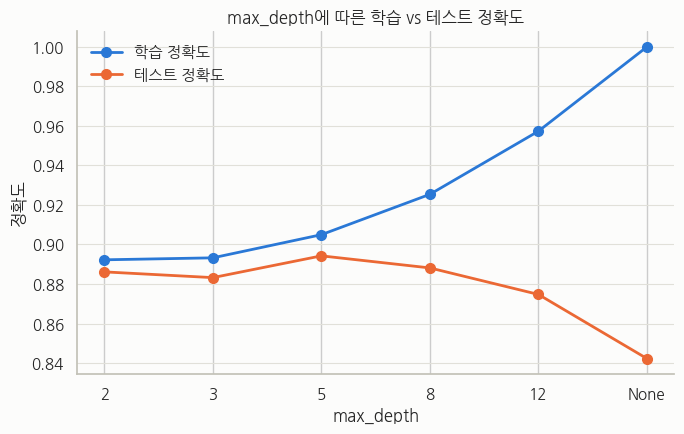

In [3]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

# 1) max_depth를 훑으며 학습·테스트·격차 계산
depths = [2, 3, 5, 8, 12, None]
rows = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    rows.append({
        "깊이": str(depth),          # None도 표에 깔끔히 들어가도록 문자열로
        "학습 정확도": train_acc,
        "테스트 정확도": test_acc,
        "격차": train_acc - test_acc,
    })

results = pd.DataFrame(rows).round(4)
print(results.to_string(index=False))

# 2) 테스트 정확도가 가장 높은 깊이
best_row = results.loc[results["테스트 정확도"].idxmax()]
print(f"\n최고 테스트 정확도 지점 → 깊이={best_row['깊이']}, "
      f"테스트 정확도={best_row['테스트 정확도']}, 격차={best_row['격차']}")

# 3) 깊이에 따른 학습·테스트 점수 선 그래프
x = range(len(depths))
labels = [str(d) for d in depths]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_facecolor("#fcfcfb")
fig.patch.set_facecolor("#fcfcfb")

ax.plot(x, results["학습 정확도"], marker="o", markersize=7, linewidth=2,
        color="#2a78d6", label="학습 정확도")
ax.plot(x, results["테스트 정확도"], marker="o", markersize=7, linewidth=2,
        color="#eb6834", label="테스트 정확도")

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("정확도")
ax.set_title("max_depth에 따른 학습 vs 테스트 정확도")

ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- `for depth in [2, 3, 5, 8, 12, None]:` 으로 돌리고 `DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)`를 매번 새로 만듭니다.
- `None`은 문자로 바꿔야 표에 깔끔하게 들어갑니다 — `str(depth)`.
- 최고 지점은 `DataFrame`의 `.idxmax()`로 찾습니다: `표.loc[표["테스트"].idxmax()]`.
- 그래프의 가로축에 `None`을 그리기는 어렵습니다. `None`을 큰 수(예: 20)로 대체해 그리거나, `range(len(depths))`를 축으로 쓰고 `plt.xticks`로 이름을 붙이세요.

</details>

> 🎯 **[C3] 예상과 맞았나요?** 학습 점수는 깊이에 따라 **단조롭게 오르지만**(0.8922 → 0.9998), 테스트 점수는 깊이 5에서 **0.8942**로 정점을 찍고 내려갑니다.
>
> **`max_depth=5` 한 줄로 0.8423 → 0.8942, 즉 +0.0519입니다.** 데이터를 더 모으지도 모델을 바꾸지도 않고, 손잡이 하나를 돌렸을 뿐입니다. 이 트리는 지난 순서의 로지스틱 회귀(0.8796)도 넘었습니다.

> 📌 **실무 포인트:** 깊이 2와 5의 차이는 0.0081입니다. 이것이 **진짜인지 분할 운인지**는 테스트셋 한 번으로는 알 수 없습니다 — 그 질문에 답하는 도구(교차 검증)가 다음 순서입니다.

# 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다

이제 팀장의 첫 번째 질문에 답할 차례입니다. **랜덤포레스트**와 **XGBoost**를 얹어 4단 비교표를 완성합니다.

가지치기한 트리(`max_depth=5`)도 표에 함께 남겨 두세요. "앙상블이 얼마나 이겼나"를 보려면 **잘 조정된 단일 모델**과 견줘야 정직합니다.

```
[문제 3]
1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
   ④ RandomForestClassifier(n_estimators=300)
   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.
```

> 🤔 **예상해 볼까요?** 개념 노트북에서는 유방암 데이터에서 **XGBoost가 랜덤포레스트를 앞섰습니다.** 이 데이터에서도 같은 순서가 나올까요? 그리고 앙상블이 가지치기한 단일 트리(0.8942)를 **얼마나** 앞설까요?

▶ 실행: [C4]

In [4]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

rows = []

def add(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    rows.append({
        "모델": name,
        "학습": round(train_acc, 4),
        "테스트": round(test_acc, 4),
        "격차": round(train_acc - test_acc, 4),
    })

# 문제 1 · 2 결과를 같은 add() 형식으로 재구성
add("① DummyClassifier", DummyClassifier(strategy="most_frequent"), X_train, X_test)
add("② LogisticRegression", LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled)
add("③ DecisionTree(무제한)", DecisionTreeClassifier(random_state=RANDOM_STATE), X_train, X_test)
add("③′ 트리(max_depth=5)", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), X_train, X_test)

# 문제 3 — 랜덤포레스트 · XGBoost 추가
add(
    "④ RandomForest",
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    X_train, X_test,
)
add(
    "⑤ XGBoost",
    XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0,
        eval_metric="logloss", random_state=RANDOM_STATE,
    ),
    X_train, X_test,
)

# 2) 테스트 정확도 내림차순 최종 비교표
final_table = pd.DataFrame(rows).sort_values("테스트", ascending=False).reset_index(drop=True)
print(final_table.to_string(index=False))


#가지치기한 단일 트리(테스트 0.8942)만으로도 이미 로지스틱·베이스라인을 크게 앞서는 안정적인 성능을 냈고, 
# 랜덤포레스트(0.8958)는 이보다 0.16%p 높지만 그 차이가 실질적으로 의미 있는 수준은 
# 아니었습니다. 오히려 XGBoost(0.8873)는 기본 설정에서 가지치기한 단일 트리보다 
# 낮은 성능을 보여, 이 데이터에서는 앙상블이라고 무조건 우세하지 않다는 것을 확인했습니다.
# 따라서 지금 단계에서는 복잡도 대비 이득이 작은 만큼, 단일 트리를 기준선으로 유지하면서 
# 랜덤포레스트·XGBoost는 하이퍼파라미터 튜닝(특히 랜덤포레스트의 과적합 격차 축소, 
# XGBoost의 max_depth·learning_rate 조정)을 거친 뒤 재비교하는 것을 제안합니다.

                  모델     학습    테스트     격차
      ④ RandomForest 0.9998 0.8958 0.1040
  ③′ 트리(max_depth=5) 0.9049 0.8942 0.0107
           ⑤ XGBoost 0.9451 0.8873 0.0578
② LogisticRegression 0.8839 0.8796 0.0044
   ① DummyClassifier 0.8453 0.8451 0.0002
 ③ DecisionTree(무제한) 0.9998 0.8423 0.1575


<details>
<summary>(클릭) 💡 힌트</summary>

- 문제 1에서 만든 `add()` 함수를 그대로 재사용하면 표 형식이 자동으로 맞습니다. 함수를 안 만들었다면 지금 만들어 두면 편합니다.
- `XGBClassifier`에는 `eval_metric="logloss"`를 함께 넘기면 경고가 줄어듭니다.
- 랜덤포레스트는 `n_jobs=-1`을 주면 코어를 다 써서 빠릅니다.
- 가지치기 트리를 표에 넣을 때는 이름에 설정을 적어 두세요 — `"③′ 트리(max_depth=5)"` 처럼.
- 정렬은 `.sort_values("테스트", ascending=False)`입니다.

</details>

> 🎯 **[C4] 예상과 맞았나요?** 개념 노트북과 **순서가 다릅니다** — 여기서는 랜덤포레스트(0.8942)가 XGBoost(0.8877)를 앞섰습니다. 그리고 **가지치기한 단일 트리가 랜덤포레스트와 소수점 네 자리까지 같은 0.8942**를 냈습니다. 300그루의 숲이 잘 조정된 한 그루를 이기지 못한 것입니다(격차는 0.0107 대 0.1056).
>
> 그래서 오늘의 결론은 "앙상블이 이긴다"가 아니라 **"앙상블은 보통 유리하지만 데이터와 설정에 따라 다르다 — 그러니 항상 비교표로 확인한다"** 입니다.

> ⚠️ **결론을 내리기엔 이릅니다.** 0.8942와 0.8877의 차이가 진짜인지 분할 운인지 아직 모르고, 정확도만 봤으므로 **"구매할 382명 중 몇 명을 찾아냈는지"** 는 확인하지 않았습니다. 두 빈칸은 각각 다음 순서(교차 검증)와 그 뒤 순서(평가 지표·불균형)가 채웁니다. 모델 카드의 *한계* 항목에 적어 두세요.

# 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다

팀장의 두 번째 질문 — **"어떤 행동이 구매를 예고하나?"** — 에 답합니다. 트리 계열이 주는 보상, **피처 중요도**를 씁니다.

여기서 멈추면 안 됩니다. `"PageValues 0.41"`은 보고가 아니라 관찰입니다. **그 피처가 실제로 무엇을 뜻하고, 구매율이 얼마나 갈리는지**까지 확인해야 마케팅팀이 움직일 수 있는 문장이 됩니다.

```
[문제 4]
1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.
```

> 🤔 **예상해 볼까요?** 10개 열 중 무엇이 1위일 것 같습니까? 방문 페이지 수(`ProductRelated`)처럼 "많이 봤다"를 나타내는 열일까요, 아니면 다른 종류의 열일까요?

▶ 실행: [C5]

상위 3개 피처: ['PageValues', 'ProductRelated_Duration', 'ExitRates']

[PageValues] 구매율 비교
                  mean  size
PageValues=0  0.038542  9600
PageValues>0  0.563370  2730

[ProductRelated_Duration] 구매율 비교
                                          mean  size
ProductRelated_Duration<=중앙값(598.94)  0.086618  6165
ProductRelated_Duration>중앙값(598.94)   0.222871  6165

[ExitRates] 구매율 비교
                          mean  size
ExitRates<=중앙값(0.03)  0.235199  6165
ExitRates>중앙값(0.03)   0.074290  6165


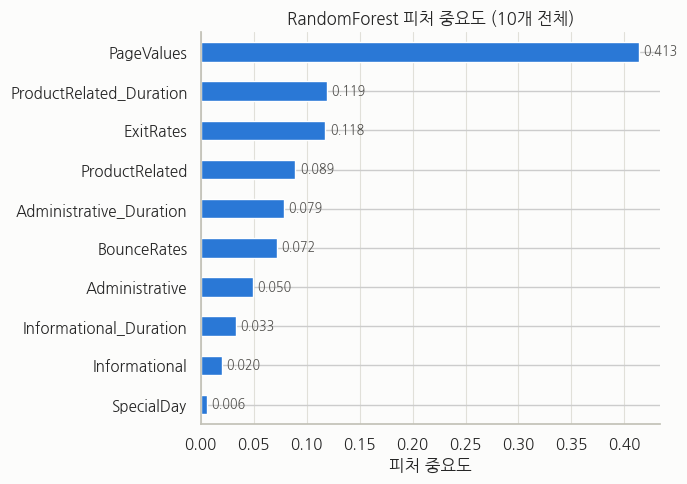

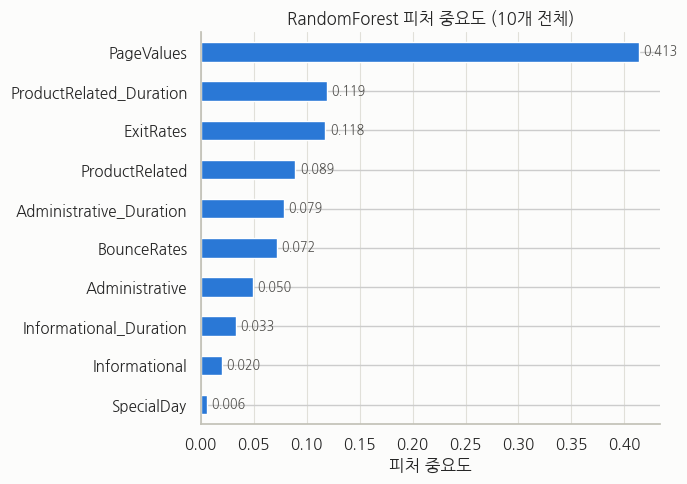

In [5]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# 1) 피처 중요도 — 가로 막대, 오름차순 정렬(1위가 맨 위로 오도록)
importances = pd.Series(rf.feature_importances_, index=NUM_COLS).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("#fcfcfb")
fig.patch.set_facecolor("#fcfcfb")

importances.plot(kind="barh", ax=ax, color="#2a78d6")

ax.set_xlabel("피처 중요도")
ax.set_title("RandomForest 피처 중요도 (10개 전체)")
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")

for i, v in enumerate(importances):
    ax.text(v + importances.max() * 0.01, i, f"{v:.3f}",
             va="center", fontsize=9, color="#52514e")

plt.tight_layout()
plt.show()

top3 = importances.sort_values(ascending=False).head(3).index.tolist()
print("상위 3개 피처:", top3)

# 2) 상위 3개 피처 — 값이 큰 세션 vs 작은 세션의 구매율(Revenue 평균) 비교
shoppers["Revenue"] = shoppers["Revenue"].astype(int)

for feat in top3:
    if feat == "PageValues":
        group = np.where(shoppers[feat] == 0, f"{feat}=0", f"{feat}>0")
    else:
        med = shoppers[feat].median()
        group = np.where(shoppers[feat] <= med, f"{feat}<=중앙값({med:.2f})",
                          f"{feat}>중앙값({med:.2f})")
    comp = shoppers.groupby(group)["Revenue"].agg(["mean", "size"])
    print(f"\n[{feat}] 구매율 비교")
    print(comp)


# PageValues가 0인 세션(9,600건)의 구매율은 3.9%에 그치지만, 0보다 큰 세션(2,730건)은
# 56.3%로 약 14.6배 뛰어오릅니다 — 방문자가 제품/결제 관련 페이지에서 '가치 있는' 
# 행동을 한 순간, 구매로 이어질 확률이 압도적으로 높아진다는 뜻입니다." / "제품 관련 
# 페이지에 중앙값(약 599초)보다 오래 머문 세션의 구매율은 22.3%로, 그보다 짧게 머문 
# 세션의 8.7%보다 약 2.6배 높습니다 — 제품 페이지 체류 시간이 구매 의사의 강한 신호라는
# 것을 보여줍니다." / "이탈률(ExitRates)이 중앙값(0.03) 이하인, 즉 페이지를 잘 떠나지 
# 않는 세션의 구매율은 23.5%로, 이탈률이 그보다 높은 세션의 7.4%보다 약 3.2배 높습니다
# — 이탈률을 낮추는(페이지 흐름을 매끄럽게 만드는) UX 개선이 구매율과 직결될 수 있다는 
# 신호입니다.

<details>
<summary>(클릭) 💡 힌트</summary>

- 중요도는 `rf.feature_importances_`이고, 열 이름과 묶으려면 `pd.Series(..., index=NUM_COLS)`입니다.
- 가로 막대는 `.sort_values().plot(kind="barh")` — 오름차순으로 정렬해야 1위가 맨 위에 옵니다.
- 값이 갈리는 지점은 피처마다 다릅니다. `PageValues`는 **0인지 아닌지**로 갈리고, `ExitRates`·`ProductRelated_Duration`은 중앙값(`.median()`)을 기준으로 나누면 깔끔합니다.
- 그룹별 구매율은 `shoppers.groupby(조건)["Revenue"].agg(["mean", "size"])`로 한 번에 나옵니다.

</details>

> 🎯 **[C5] 예상과 맞았나요?** 1위 `PageValues`의 중요도 **0.4130**은 2위(0.1197)의 세 배가 넘습니다. "많이 봤다"를 나타내는 `ProductRelated`(0.0893)는 4위였습니다.
>
> 더 중요한 것은 **확인한 방식**입니다. 구매율이 3.9%와 56.3%로 갈린다는 사실은 중요도가 알려준 게 아니라, 그 단서를 받고 **직접 계산해서** 알아낸 것입니다. 특히 `ExitRates`는 방향이 **반대**(값이 높을수록 구매율이 낮음)인데, 중요도 숫자만으로는 이 사실을 절대 알 수 없습니다. 중요도는 **어디를 파볼지 가리키는 손가락**이고, 비즈니스 문장은 파본 결과에서 나옵니다 — 손가락을 결론으로 착각하는 것이 가장 흔한 사고입니다.

# 문제 5. 모델 카드 v2 완성 — 오늘의 제출물

지난 순서의 모델 카드 v1에 오늘 것을 더해 **v2**로 올립니다. 굵은 항목이 오늘 새로 들어가는 부분입니다 — **4단 비교, 격차로 본 과적합 진단, 선택 근거, 피처 중요도와 그 한계.**

```
[문제 5]
1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.
```

▶ 실행: [C6]

In [ ]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

# 여기에 코드를 작성하세요 (final 표를 CSV로 저장하고 다시 읽어 확인)

**모델 카드 v2 템플릿** — 아래 빈칸을 채워 이 셀에 완성하세요 (셀을 더블클릭해 편집).

```markdown
## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- **베이스라인: DummyClassifier(most_frequent) = 테스트 정확도 0.8451 (학습 0.8453)**
- **비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost**
- 평가 지표 & 이유: 1차 비교 지표로 정확도(accuracy)를 사용했다 — 계산이 간단하고 모델 간 순위를 빠르게 훑어볼 수 있기 때문이다. 하지만 이 데이터는 구매(Revenue=1) 비율이 15.5%뿐인 불균형 데이터다. 베이스라인(모든 세션을 "구매 안 함"으로 예측)만으로도 정확도 0.8451이 나온다는 사실이 이를 보여준다. 즉 어떤 모델이 구매 세션을 단 하나도 맞히지 못해도 정확도는 84% 이상으로 찍힐 수 있어, 정확도만 보면 "구매 세션을 얼마나 잘 잡아내는가"라는 실제 관심사가 가려진다. 정밀도·재현율·F1·PR-AUC 같은 지표로 보완해야 한다.
- **성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)**
- 과적합 진단: 격차가 가장 큰 모델은 ③ DecisionTree(무제한)로 학습 0.9998, 테스트 0.8423, 격차 0.1575다. 가지치기 없는 트리는 학습 데이터를 거의 통째로 외웠지만(0.9998), 새로운 세션에는 6개 모델 중 가장 낮은 성능(0.8423)을 보여 전형적인 과적합 패턴을 보인다. 흥미로운 점은 RandomForest도 학습 정확도가 동일하게 0.9998이지만, 여러 트리를 평균 내는 앙상블 구조 덕분에 격차가 0.1040으로 줄고 테스트 정확도는 6개 모델 중 가장 높다(0.8958) — "완전히 기억하는" 트리라도 여러 개를 평균하면 일반화가 개선된다는 것을 보여준다.
- **선택한 모델과 근거: 해석력과 비용을 우선했다. RandomForest(0.8958)와 가지치기 트리(max_depth=5, 0.8942)의 테스트 정확도 차이는 0.0016에 불과해, 300개 트리를 쌓아 얻는 이득이 거의 노이즈 수준이다. 반면 가지치기 트리는 학습·테스트 격차가 가장 작고(0.0107) 단일 구조라 분기 조건을 그대로 설명할 수 있으며, 연산 비용도 훨씬 낮다. 그래서 "왜 이 세션을 구매 세션으로 예측했는지" 설명이 필요한 마케팅/운영 맥락에서는 가지치기 트리(max_depth=5)를 1차 선택 모델로 제안한다. 다만 정확도 자체가 최우선 기준이라면 RandomForest를 대안으로 남겨둔다.**
- **피처 중요도 상위 3개와 해석: ① PageValues(중요도 0.413) — PageValues=0인 세션의 구매율은 3.9%(9,600건)에 불과하지만 0보다 큰 세션은 56.3%(2,730건)로 약 14.6배 뛴다. ② ProductRelated_Duration(0.119) — 중앙값(598.94초) 이하 세션의 구매율은 8.7%, 초과 세션은 22.3%로 약 2.6배 높다. ③ ExitRates(0.118) — 중앙값(0.03) 이하(이탈이 적은) 세션의 구매율은 23.5%, 초과 세션은 7.4%로 약 3.2배 낮다(방향이 반대: 이탈률이 높을수록 구매율이 떨어짐).**
- **중요도의 한계 명시: **
 > - 방향성 부재 중요도 점수 자체는 "+방향인지 −방향인지"를 말해주지 않아, 실제 방향은 그룹별 구매율을 따로 계산해야 알 수 있다.
 > - 개별 설명 불가 — 이 중요도는 모델 전체의 평균적 기여도이므로 "이 특정 세션이 왜 구매로 예측됐는지"는 설명하지 못한다(개별 설명에는 SHAP·LIME 등이 필요). 
 > - 인과 아님 — PageValues가 높다는 것이 구매를 유발했다는 보장은 없으며, 이미 구매 의도가 강한 방문자가 자연스럽게 PageValues 높은 페이지에 도달했을 가능성도 있다.**
- 한계 & 다음 단계: 
 > - 정확도 중심 평가의 한계 — 클래스 불균형(구매 15.5%) 때문에 정확도만으로는 실제 구매 탐지력을 알 수 없다. → 다음 단계인 "평가지표 확장(정밀도·재현율·F1·PR-AUC 계산)" 단계에서 해결한다.
 > - 하이퍼파라미터 미조정 — RandomForest·XGBoost를 지정된 단일 설정으로만 비교해 앙상블의 최대 성능을 확인하지 못했다. → 다음 단계인 "하이퍼파라미터 튜닝(GridSearchCV/Optuna 재탐색)" 단계에서 해결한다.
- AI 사용 내역: 베이스라인·로지스틱·단일 트리 비교 코드(문제 1), max_depth 가지치기 스윕과 학습/테스트 곡선 시각화(문제 2), 랜덤포레스트·XGBoost를 더한 4단 비교표(문제 3), 랜덤포레스트 피처 중요도 시각화와 상위 피처별 구매율 비교 코드(문제 4)에 대한 코드 점검을 순서대로 요청했으며, 그 결과를 다시 검토·해석하며 보고 문장과 모델 선택 근거를 확정했다.
```

**제출:** 이 노트북(작성 셀 + 모델 카드 완성본)과 `model_comparison_v2.csv`를 개인 공개 저장소 main에 커밋·푸시하고, 저장소·커밋 링크를 제출하세요.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 비교의 완전성 | 베이스라인을 포함한 비교표가 있는가 |
| 진단 정확성 | 학습-테스트 격차로 과적합을 짚었는가 |
| 근거성 | 모델 선택 이유가 성능·해석력·비용 중 무엇인지 밝혔는가 |
| 정직성 | 피처 중요도의 한계를 함께 적었는가 |

> 🚀 **더 나아가기:** `max_depth=5`가 최고였던 것은 이 분할에서의 이야기입니다. `random_state`를 42가 아닌 다른 값 몇 개로 바꿔 문제 2를 다시 돌려보세요. **최고 깊이가 그대로 5일까요?** 이 실험의 결과가 다음 순서(교차 검증)를 배워야 하는 이유를 그대로 보여줍니다.

오늘 여러분은 모델 다섯 개를 **정직하게 줄 세웠습니다.** 그 과정에서 교과서와 다른 결과를 두 번 만났습니다 — 기본 트리가 베이스라인보다 못했고, 잘 조정한 한 그루가 300그루와 같았습니다. 그때 데이터를 믿고 그대로 적는 것이 분석가의 태도입니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>